# Lab 13 — Line Codes, Scramblers, Eyes and Jitter: The Serial-Link Toolkit

**Companion to Chapter 8** (*Baseband Transmission and Pulse Shaping*).
**Time needed:** about 90 minutes. **Difficulty:** core.

Every wire that carries bits, from a T1 span to a 112 Gb/s SerDes lane, has to solve the same
problems: keep the signal free of DC so it passes transformers and AC-coupling capacitors, make
enough transitions for the receiver to recover its clock, fit through a channel that attenuates
high frequencies by tens of dB, and meet a bit error rate of $10^{-12}$ or better despite jitter.
This lab is the toolkit: line codes and their spectra, scramblers and 8b/10b, jitter and bathtub
curves, NRZ versus PAM-4 over a lossy backplane with a feed-forward equalizer, and duobinary
partial response. (Lab 3 covers Nyquist pulses and matched filtering.)

### What you will learn
1. Draw and recognise the classic line codes, and predict their power spectra, including spectral lines.
2. Generate PRBS sequences, scramble data, and see why 8b/10b bounds run length and DC wander.
3. Decompose jitter into random and deterministic parts and read a bathtub curve.
4. Compare NRZ and PAM-4 over a lossy channel, before and after a feed-forward equalizer.
5. Use duobinary signalling with precoding to avoid error propagation.

### Prerequisites
Lab 3 (pulses, eyes, matched filter). PSD of a random process (Chapter 3). Chapter 8.

### Roadmap
| § | Topic | Interactive |
|---|-------|:-----------:|
| 1 | A gallery of line codes | |
| 2 | Power spectra and spectral lines | |
| 3 | PRBS, scramblers and error multiplication | |
| 4 | 8b/10b: run length and running disparity | |
| 5 | Jitter, eyes and bathtub curves | yes |
| 6 | NRZ vs PAM-4 over a lossy backplane, with FFE | yes |
| 7 | Duobinary and precoding | |

In [1]:
import os, sys
os.environ.setdefault("OPENBLAS_NUM_THREADS", "2")   # small matrices: avoid BLAS thread thrashing
sys.path[:0] = [p for p in (os.path.abspath(".."), os.path.abspath("."))
                if os.path.isdir(os.path.join(p, "commlib"))]
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch
import commlib as cl
from commlib import linecodes as lc
from commlib import labkit as lk

rng = lk.setup(seed=13, lab="13")

Lab 13 ready | numpy 2.5.3 | scipy 1.18.1 | matplotlib 3.11.2 | seed 13


## 1. A gallery of line codes

* **NRZ** (polar): +1 for a one, −1 for a zero. Simple and bandwidth-efficient, but a long run of
  identical bits has no transitions and a DC component that depends on the data.
* **NRZI**: a one is a *transition*; immune to polarity inversion (USB, with bit stuffing).
* **Unipolar RZ**: pulses for ones only, half a bit wide: easy clock extraction, wasteful of power.
* **Manchester** (10BASE-T Ethernet): every bit has a mid-bit transition; zero DC, twice the bandwidth.
* **AMI / bipolar** (T1, E1): zeros are 0 V, ones alternate ±: zero DC, and a violation reveals an error.
  B8ZS/HDB3 substitute deliberate violations for long zero runs to keep the clock alive.
* **MLT-3** (100BASE-TX): cycles 0, +1, 0, −1 on each one; concentrates energy below $R_b/4$.
* **2B1Q** (ISDN) and **PAM-4** (400G Ethernet, PCIe 6.0): two bits per four-level symbol, half the baud rate.

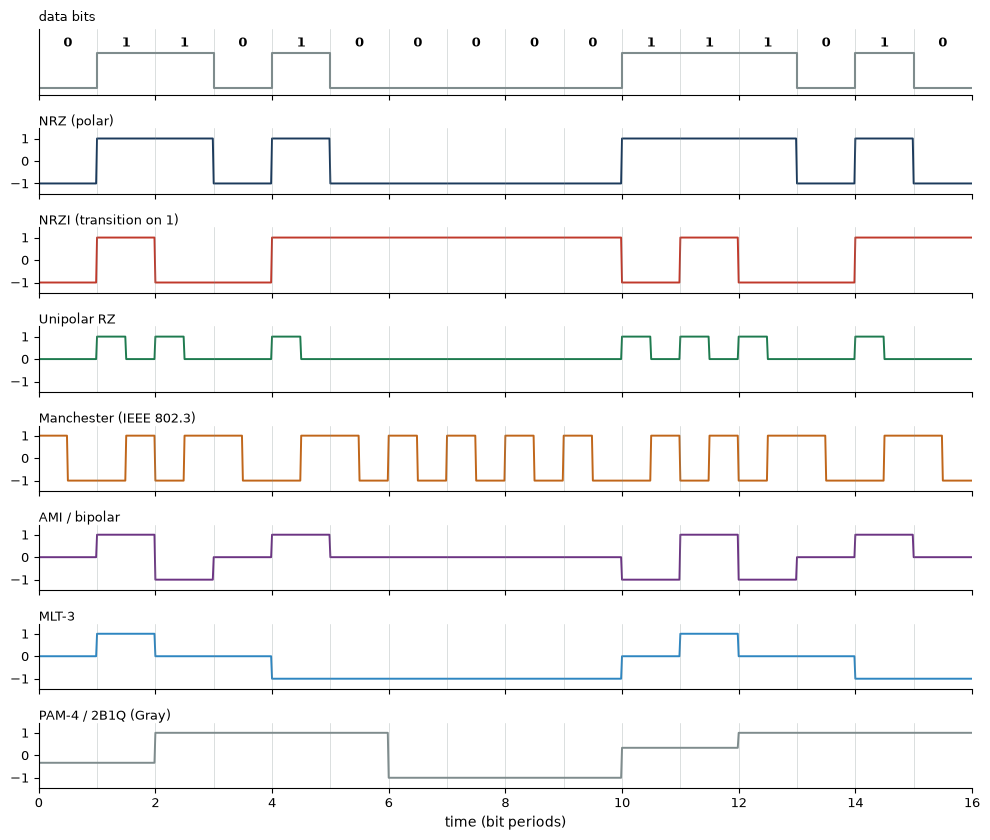

In [3]:
bits = np.array([0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0])
s = 64
codes = [("NRZ (polar)", "nrz"), ("NRZI (transition on 1)", "nrzi"), ("Unipolar RZ", "urz"),
         ("Manchester (IEEE 802.3)", "manchester"), ("AMI / bipolar", "ami"), ("MLT-3", "mlt3"),
         ("PAM-4 / 2B1Q (Gray)", "pam4")]
f, ax = lk.fig((10, 8.5), len(codes) + 1, 1, sharex=True)
t = np.arange(len(bits) * s) / s
ax[0].step(np.arange(len(bits) + 1), np.r_[bits, bits[-1]], where="post", color=lk.GRAY)
for i, b in enumerate(bits):
    ax[0].text(i + 0.5, 1.2, str(b), ha="center", fontsize=9, fontweight="bold")
ax[0].set_ylim(-0.2, 1.7); ax[0].set_yticks([]); ax[0].set_title("data bits", loc="left", fontsize=9)
for k, (name, c) in enumerate(codes, start=1):
    ax[k].plot(t, lc.encode_line(bits, c, s), color=lk.PALETTE[(k - 1) % 7], lw=1.4)
    ax[k].set_ylim(-1.45, 1.45); ax[k].set_yticks([-1, 0, 1]); ax[k].set_title(name, loc="left", fontsize=9, pad=2)
for a in ax:
    for kk in range(len(bits) + 1):
        a.axvline(kk, color=lk.GRAY, lw=0.4, alpha=0.5)
    a.grid(False)
ax[-1].set_xlim(0, len(bits)); ax[-1].set_xlabel("time (bit periods)")
lk.show(f)

**What you should see.** The same 16 bits, seven ways. Look for the run of five zeros in the middle:
NRZ and AMI go flat (no transitions to recover a clock from), while Manchester keeps ticking.

## 2. Power spectra and spectral lines

For a PAM signal $\sum_k a_k p(t-kT)$ with i.i.d. symbols of mean $\mu_a$ and variance $\sigma_a^2$,

$$S(f) = \frac{\sigma_a^2}{T}|P(f)|^2 + \frac{\mu_a^2}{T^2}\sum_m \left|P\!\left(\tfrac{m}{T}\right)\right|^2\delta\!\left(f-\tfrac{m}{T}\right).$$

A non-zero mean produces **spectral lines** at multiples of the bit rate, weighted by the pulse
spectrum there: unipolar NRZ has only a DC line (its sinc has zeros at the other multiples), while
unipolar RZ has lines at $R_b$, $3R_b$, ... which a simple tuned circuit can use as a clock. Codes with
correlated symbols (Manchester, AMI) shape the continuous part: both have a null at DC.
Analytic continuous parts (dashed) with $T = 1$:
polar NRZ $\mathrm{sinc}^2 f$; Manchester $\mathrm{sinc}^2(f/2)\sin^2(\pi f/2)$; AMI $\mathrm{sinc}^2 f\,\sin^2\pi f$;
unipolar NRZ $\tfrac14\mathrm{sinc}^2 f$; unipolar RZ $\tfrac1{16}\mathrm{sinc}^2(f/2)$.

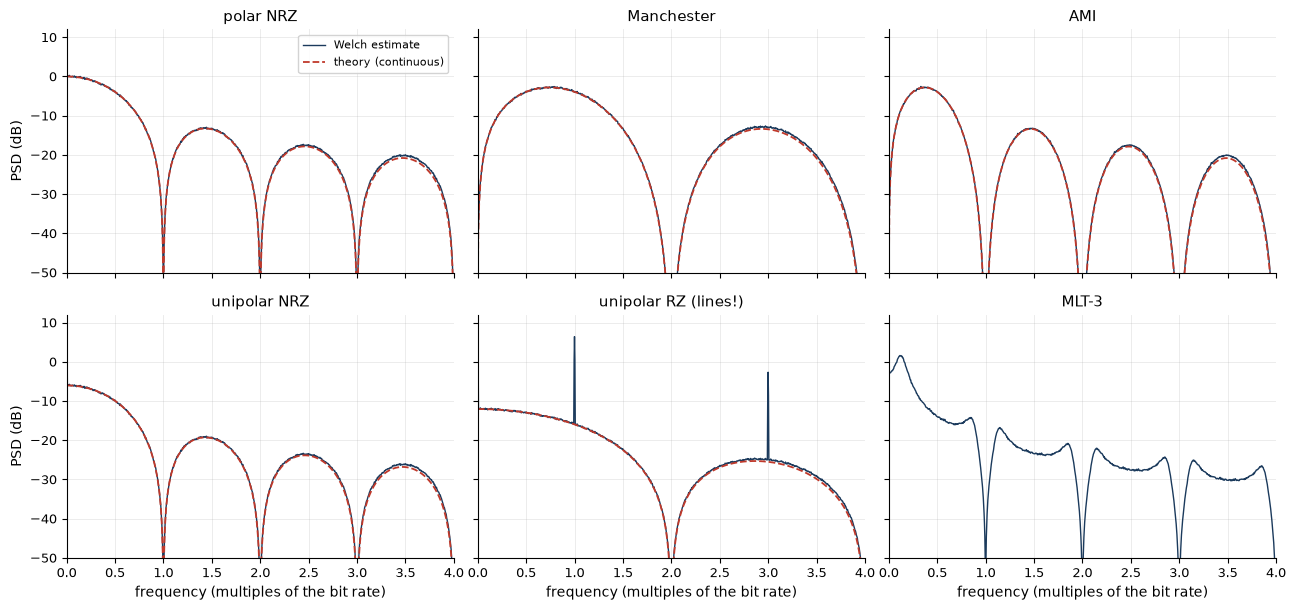

In [6]:
sinc2 = lambda x: np.sinc(x) ** 2
theory = {"nrz": lambda fr: sinc2(fr), "manchester": lambda fr: sinc2(fr / 2) * np.sin(np.pi * fr / 2) ** 2,
          "ami": lambda fr: sinc2(fr) * np.sin(np.pi * fr) ** 2, "unrz": lambda fr: 0.25 * sinc2(fr),
          "urz": lambda fr: sinc2(fr / 2) / 16, "mlt3": None}
names = {"nrz": "polar NRZ", "manchester": "Manchester", "ami": "AMI", "unrz": "unipolar NRZ",
         "urz": "unipolar RZ (lines!)", "mlt3": "MLT-3"}
sps = 16
bits_psd = cl.random_bits(200_000, rng)
f, axs = lk.fig((13, 6.2), 2, 3, sharex=True, sharey=True)
for ax, (c, name) in zip(axs.ravel(), names.items()):
    x = lc.encode_line(bits_psd, c, sps)
    fr, p = welch(x, fs=sps, nperseg=4096, return_onesided=False, detrend=False)
    keep = fr >= 0
    ax.plot(fr[keep], lk.db(p[keep]), color=lk.NAVY, lw=1, label="Welch estimate")
    if theory[c] is not None:
        ff = np.linspace(0.001, 4, 800)
        ax.plot(ff, lk.db(theory[c](ff)), "--", color=lk.RED, lw=1.3, label="theory (continuous)")
    ax.set_title(name); ax.set_xlim(0, 4); ax.set_ylim(-50, 12)
for ax in axs[1]:
    ax.set_xlabel("frequency (multiples of the bit rate)")
for ax in axs[:, 0]:
    ax.set_ylabel("PSD (dB)")
axs[0, 0].legend(fontsize=8)
lk.show(f)

**What you should see.** Welch (solid) lies on theory (dashed) for every code. The spikes are the
spectral lines: at DC for unipolar NRZ, at DC and odd multiples of $R_b$ for unipolar RZ (the even
ones fall in the nulls of $\mathrm{sinc}(f/2)$). Manchester and AMI have nulls at DC; Manchester's
main lobe extends to $2R_b$, AMI's to $R_b$. MLT-3 packs most power below $R_b/2$, which is why
100 Mb/s Ethernet fits over Cat-5 cable with a 31.25 MHz main lobe.

### Try it yourself 2.1
What fraction of the total power of unipolar NRZ sits in the DC spectral line?
(Mean squared over mean square: think about $\mu_a^2$ versus $E[a^2]$.)

In [8]:
answer_2_1 = None
lk.check("2.1 fraction of unipolar NRZ power in the DC line", answer_2_1, 0.5, atol=0.01)

[TODO] 2.1 fraction of unipolar NRZ power in the DC line: not attempted yet: replace the None with your answer

## 3. PRBS, scramblers and error multiplication

A **linear-feedback shift register** with a primitive polynomial of degree $n$ cycles through all
$2^n - 1$ non-zero states: a **pseudo-random binary sequence** (PRBS-7, -15, -31 are the standard test
patterns of ITU-T O.150 and every SerDes compliance test). Its periodic autocorrelation is two-valued:
$2^n - 1$ at zero lag and $-1$ elsewhere, which makes it look almost like white noise.

A **scrambler** XORs the data with such a sequence so that long runs and periodic patterns in the data
become random-looking on the line. The **self-synchronous** scrambler of 64b/66b Ethernet,
$s_n = d_n \oplus s_{n-39} \oplus s_{n-58}$, needs no frame alignment (the descrambler uses the received
bits), at the price of **error multiplication**: one line error corrupts three output bits.

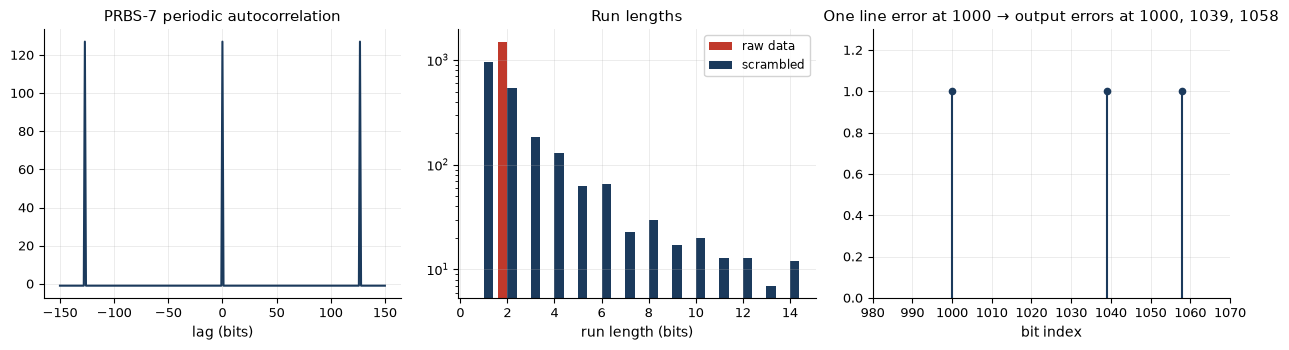

In [10]:
p7 = lc.prbs(7, 127 * 4)
pm = 2.0 * p7[:127] - 1
acf = np.array([np.dot(pm, np.roll(pm, k)) for k in range(-150, 151)])
data = np.r_[np.zeros(3000, dtype=np.int8), np.tile(np.array([1, 1, 0, 0], np.int8), 750)]   # nasty data
scr = lc.scramble_ss(data)
f, ax = lk.fig("row3", 1, 3)
ax[0].plot(np.arange(-150, 151), acf, color=lk.NAVY); ax[0].set_title("PRBS-7 periodic autocorrelation")
ax[0].set_xlabel("lag (bits)")
ax[1].hist([lc.run_lengths(data), lc.run_lengths(scr)], bins=np.arange(1, 16) - 0.5, log=True,
           color=[lk.RED, lk.NAVY], label=["raw data", "scrambled"])
ax[1].set_xlabel("run length (bits)"); ax[1].set_title("Run lengths"); ax[1].legend()
# error multiplication
d = cl.random_bits(2000, rng)
rx = lc.scramble_ss(d); rx[1000] ^= 1
err = np.flatnonzero(lc.descramble_ss(rx) != d)
ax[2].stem(err, np.ones(len(err)), basefmt=" ")
ax[2].set_xlim(980, 1070); ax[2].set_ylim(0, 1.3); ax[2].set_xlabel("bit index")
ax[2].set_title(f"One line error at 1000 → output errors at {', '.join(str(int(e)) for e in err)}")
lk.show(f)

**What you should see.** An autocorrelation with peaks of 127 every 127 lags and −1 in between. The raw
data has a run of 3000 zeros (off the chart, at the right edge) and runs of exactly 2; after scrambling
the run lengths follow the geometric law of random bits. One line error produces exactly three
descrambler errors, 39 and 58 bits apart.

### Try it yourself 3.1
What is the period (in bits) of PRBS-31?

In [12]:
answer_3_1 = None
lk.check("3.1 period of PRBS-31", answer_3_1, 2 ** 31 - 1, atol=0)

[TODO] 3.1 period of PRBS-31: not attempted yet: replace the None with your answer

## 4. 8b/10b: run length and running disparity

Scrambling makes long runs *unlikely*; 8b/10b (Widmer and Franaszek, IBM 1983; Fibre Channel,
Gigabit Ethernet, PCIe 1–2, SATA, USB 3.0) makes them *impossible*. Each byte becomes a 10-bit
character with at most five identical bits in a row, and the encoder chooses between two versions of
unbalanced characters to keep the **running disparity** (ones minus zeros) within ±1 at character
boundaries, so the **running digital sum** (the DC wander) stays bounded no matter the data. The price
is 25% overhead, which is why 10G+ Ethernet moved to 64b/66b and PCIe 3+ to 128b/130b with scrambling.

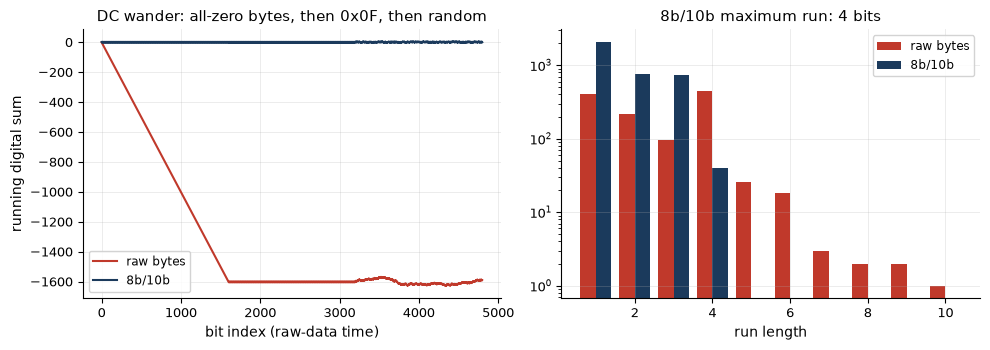

In [14]:
nasty = np.r_[np.zeros(200, dtype=int), np.full(200, 0x0F), rng.integers(0, 256, 200)]   # bytes
raw_bits = ((nasty[:, None] >> np.arange(7, -1, -1)) & 1).ravel()
enc, rd = lc.enc8b10b(nasty, return_rd=True)
f, ax = lk.fig("row2", 1, 2)
ax[0].plot(lc.running_digital_sum(raw_bits), color=lk.RED, label="raw bytes")
ax[0].plot(np.linspace(0, len(raw_bits), len(enc)), lc.running_digital_sum(enc), color=lk.NAVY, label="8b/10b")
ax[0].set_xlabel("bit index (raw-data time)"); ax[0].set_ylabel("running digital sum")
ax[0].set_title("DC wander: all-zero bytes, then 0x0F, then random"); ax[0].legend()
ax[1].hist([lc.run_lengths(raw_bits), lc.run_lengths(enc)], bins=np.arange(1, 12) - 0.5, log=True,
           color=[lk.RED, lk.NAVY], label=["raw bytes", "8b/10b"])
ax[1].set_xlabel("run length"); ax[1].set_title(f"8b/10b maximum run: {lc.run_lengths(enc).max()} bits")
ax[1].legend()
lk.show(f)

**What you should see.** The raw running digital sum dives to −1600 during the zero bytes (a
transformer-coupled line would lose its baseline), while the 8b/10b sum stays within a few units, and
no 8b/10b run ever exceeds five bits (the raw data had runs of 1600).

### Try it yourself 4.1
64b/66b adds a 2-bit sync header to each 64-bit block. What is its overhead, in percent?

In [16]:
answer_4_1 = None
lk.check("4.1 overhead of 64b/66b (%)", answer_4_1, 100 * 2 / 64, atol=0.01)

[TODO] 4.1 overhead of 64b/66b (%): not attempted yet: replace the None with your answer

## 5. Jitter, eyes and bathtub curves

Real transitions do not land exactly on the bit grid. Jitter is split into **random jitter** (RJ,
Gaussian with RMS $\sigma$, from thermal and phase noise, unbounded) and **deterministic jitter** (DJ,
bounded: ISI, duty-cycle distortion, crosstalk). The **dual-Dirac** model approximates DJ by two equal
impulses $\pm \mathrm{DJ}/2$. For a sampling phase $x$ (in UI) and transition density $\rho = 1/2$,

$$\mathrm{BER}(x) = \frac{\rho}{2}\sum_\pm\left[Q\!\left(\frac{x \pm \mathrm{DJ}/2}{\sigma}\right)
+ Q\!\left(\frac{1 - x \pm \mathrm{DJ}/2}{\sigma}\right)\right].$$

Plotted against $x$ this is the **bathtub curve**. Its width at $10^{-12}$ is the eye opening, and the
**total jitter** is $\mathrm{TJ}(10^{-12}) = \mathrm{DJ} + 2\times 7.03\,\sigma$ (for $\rho = 1/2$,
$Q^{-1}$ evaluated at $2\times10^{-12}$ gives 7.03).

### Interactive: jitter budget

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

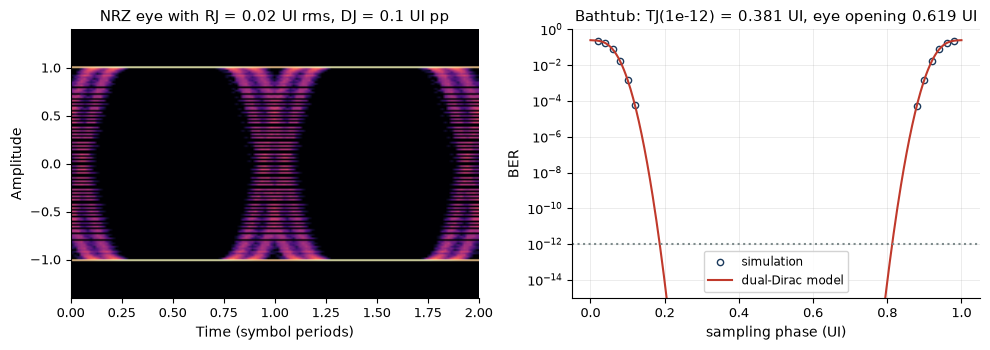

In [18]:
from scipy.special import erfc
Q = lambda x: 0.5 * erfc(np.asarray(x) / np.sqrt(2))

def jitter_demo(rj_ui=0.02, dj_ui=0.1):
    n = 1_500_000
    b = cl.random_bits(n, rng)
    edge = rj_ui * rng.standard_normal(n) + dj_ui / 2 * rng.choice([-1, 1], n)   # edge k at time k + edge[k]
    trans = np.r_[False, b[1:] != b[:-1]]
    xs = np.linspace(0.02, 0.98, 49)
    ber_sim = []
    for x in xs:   # sample bit k at time k + x: wrong if its left edge is late, or next edge early
        e = (trans & (edge > x)) | (np.r_[trans[1:], False] & (np.r_[edge[1:], 0] + 1 < x))
        ber_sim.append(e.mean())
    xf = np.linspace(0, 1, 400)
    th = sum(0.25 * (Q((xf + s_ * dj_ui / 2) / rj_ui) + Q((1 - xf + s_ * dj_ui / 2) / rj_ui)) for s_ in (-1, 1))
    # an eye diagram: build at 256 samples/UI (fine edge timing), smooth (finite rise time),
    # then keep every 8th sample -> 32 samples/UI
    m, fine = 3000, 256
    tt = np.arange(m * fine) / fine
    k = np.searchsorted(np.arange(m) + edge[:m], tt) - 1
    wave = 2.0 * b[np.clip(k, 0, m - 1)] - 1
    wave = np.convolve(wave, np.hanning(97) / np.hanning(97).sum(), mode="same")[::8]
    spu = fine // 8
    f, ax = lk.fig("row2", 1, 2)
    lk.eye_density(ax[0], wave[200 * spu:], spu, 2, ylim=1.4, upsample=2)
    ax[0].set_title(f"NRZ eye with RJ = {rj_ui} UI rms, DJ = {dj_ui} UI pp")
    ax[1].semilogy(xs, np.where(np.array(ber_sim) > 0, ber_sim, np.nan), "o", color=lk.NAVY, mfc="white", label="simulation")
    ax[1].semilogy(xf, th, color=lk.RED, label="dual-Dirac model")
    ax[1].axhline(1e-12, color=lk.GRAY, ls=":")
    tj = dj_ui + 2 * 7.03 * rj_ui
    ax[1].set_ylim(1e-15, 1); ax[1].set_xlabel("sampling phase (UI)"); ax[1].set_ylabel("BER"); ax[1].legend()
    ax[1].set_title(f"Bathtub: TJ(1e-12) = {tj:.3f} UI, eye opening {max(1 - tj, 0):.3f} UI")
    lk.show(f)

lk.interact(jitter_demo, rj_ui=lk.slider(0.02, 0.005, 0.06, 0.005, "RJ (UI rms)"),
            dj_ui=lk.slider(0.1, 0, 0.4, 0.02, "DJ (UI pp)"))

**What you should see.** The simulation (open circles, down to about $10^{-6}$) sits on the model,
which extrapolates to $10^{-12}$ and beyond: that extrapolation is exactly what a SerDes compliance
tester does, because nobody waits for $10^{12}$ bits per sampling phase. Double RJ and the bathtub
walls tilt out much more than if you double DJ: at $10^{-12}$ each unit of RJ counts 14 times.

### Try it yourself 5.1
A 25 Gb/s link has 0.15 UI of DJ and 0.015 UI rms of RJ. What is TJ at $10^{-12}$, in picoseconds?

In [20]:
answer_5_1 = None
lk.check("5.1 TJ(1e-12) in ps", answer_5_1, (0.15 + 14.06 * 0.015) * 40, atol=0.3, hint="1 UI = 40 ps at 25 Gb/s")

[TODO] 5.1 TJ(1e-12) in ps: not attempted yet: replace the None with your answer

## 6. NRZ vs PAM-4 over a lossy backplane, with FFE

A copper backplane attenuates as $a\sqrt f$ (skin effect) plus $bf$ (dielectric loss). At 56 Gb/s,
NRZ puts its Nyquist frequency at 28 GHz; PAM-4 sends two bits per symbol at 28 GBd, Nyquist 14 GHz,
where the loss is much lower. But PAM-4 has three eyes stacked in the same swing, each one third as
tall: a $20\log_{10}3 = 9.5$ dB penalty. Whether PAM-4 wins depends on how much more loss NRZ suffers
at twice the frequency. A **feed-forward equalizer** (FFE: a short symbol-spaced FIR, here designed
by zero-forcing on the pulse response) undoes most of the ISI.

### Interactive: channel loss

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

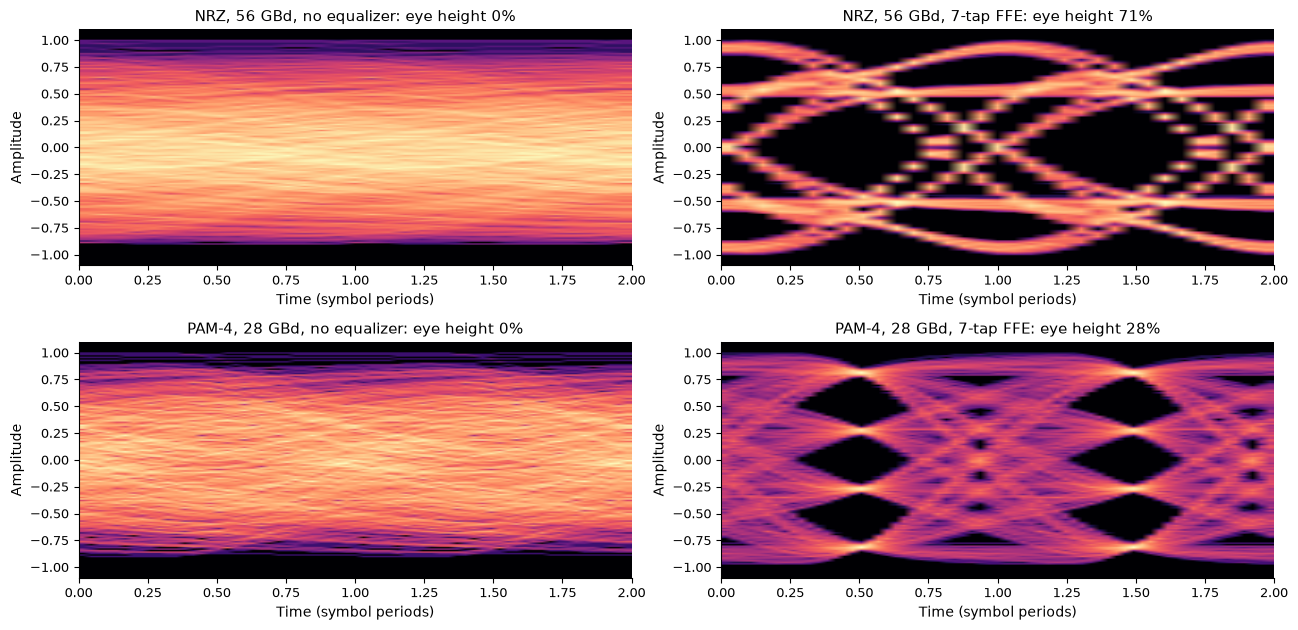

,value
loss at 28 GHz (NRZ Nyquist),25.0 dB
loss at 14 GHz (PAM-4 Nyquist),14.6 dB
"NRZ, 56 GBd, no equalizer",0% of outer-level spacing
"NRZ, 56 GBd, 7-tap FFE",71% of outer-level spacing
"PAM-4, 28 GBd, no equalizer",0% of outer-level spacing
"PAM-4, 28 GBd, 7-tap FFE",28% of outer-level spacing


In [22]:
def eye_opening(y, sps_, levels, max_lag=120):
    """Best sampling phase, alignment lag and worst-case inner-eye height (fraction of the
    distance between the outer levels) of waveform y carrying the symbol sequence `levels`."""
    u = np.unique(levels)
    n = len(levels) - max_lag - 40
    best = (-np.inf, 0, 0)
    for ph in range(sps_):
        samp = y[ph::sps_]
        lag = int(np.argmax([np.dot(samp[l_:l_ + 2000], levels[:2000]) for l_ in range(max_lag)]))
        sm, lv = samp[lag + 20:lag + n], levels[20:n]
        lo, hi = np.median(sm[lv == u[0]]), np.median(sm[lv == u[-1]])
        gaps = [sm[lv == u[i + 1]].min() - sm[lv == u[i]].max() for i in range(len(u) - 1)]
        eh = min(gaps) / (hi - lo)
        if eh > best[0]:
            best = (eh, ph, lag)
    return best

def backplane_demo(loss_db=25.0, ffe_taps=7):
    spb = 16                                   # samples per NRZ bit
    fs = 56e9 * spb
    h = lc.backplane(fs, loss_db, 28e9, nfft=1 << 14, length=1200)
    bb = cl.random_bits(6000, rng)
    rows = []
    f_, axs = lk.fig((13, 6.4), 2, 2)
    for r_, (name, code, sps_) in enumerate([("NRZ, 56 GBd", "nrz", spb), ("PAM-4, 28 GBd", "pam4", 2 * spb)]):
        x = lc.encode_line(bb, code, spb)
        levels = x[::sps_]
        y = np.convolve(x, h)[:len(x)]
        w, _, _ = lc.ffe_zf(lc.pulse_response(h, sps_), sps_, ntaps=ffe_taps, pre=1)
        yeq = np.zeros_like(y)
        for k_, wk in enumerate(w):            # symbol-spaced FIR applied to the oversampled waveform
            yeq[k_ * sps_:] += wk * y[:len(y) - k_ * sps_]
        for c_, (yy, lab) in enumerate([(y, "no equalizer"), (yeq, f"{ffe_taps}-tap FFE")]):
            eh, ph, lag = eye_opening(yy, sps_, levels)
            start = ph + (lag + 30) * sps_ - sps_ // 2            # eye centred at 0.5 UI
            seg = yy[start:start + 3000 * sps_ // (2 if sps_ > spb else 1)]
            lk.eye_density(axs[r_, c_], seg / np.max(np.abs(seg)), sps_, 2, ylim=1.1, upsample=1)
            axs[r_, c_].set_title(f"{name}, {lab}: eye height {max(eh, 0) * 100:.0f}%")
            rows.append([f"{name}, {lab}", f"{max(eh, 0) * 100:.0f}% of outer-level spacing"])
    lk.show(f_)
    il = lambda fq: loss_db * (0.4 * np.sqrt(fq / 28e9) + 0.6 * fq / 28e9)
    lk.table([["loss at 28 GHz (NRZ Nyquist)", f"{il(28e9):.1f} dB"],
              ["loss at 14 GHz (PAM-4 Nyquist)", f"{il(14e9):.1f} dB"]] + rows, ["", "value"])

lk.interact(backplane_demo, loss_db=lk.slider(25, 5, 40, 1, "loss at 28 GHz (dB)"),
            ffe_taps=lk.islider(7, 2, 15, 1, "FFE taps"))

**What you should see.** Without equalization the NRZ eye at 25 dB loss is closed; PAM-4, seeing
about 10 dB less loss, is closed too (three small eyes need more). With the FFE both open. Slide the
loss down to about 10 dB and NRZ wins clearly (bigger eye, no 9.5 dB penalty); slide it up to 35 dB
and the NRZ eye stays shut while PAM-4 still opens. This is the arithmetic behind 400G Ethernet's
53 GBd PAM-4 lanes (IEEE 802.3bs/ck) and PCIe 6.0's move to PAM-4.

## 7. Duobinary and precoding

Partial response gives up zero ISI on purpose. **Duobinary** sends $y_k = a_k + a_{k-1}$: the
end-to-end pulse is $\mathrm{sinc}(t) + \mathrm{sinc}(t-1)$, whose spectrum $2T\cos(\pi fT)$ fits in
exactly $R_b/2$ with no excess bandwidth and rolls off gently (realisable). The eye has three levels,
$\{-2, 0, +2\}$. Recovering $a_k$ as $\hat a_k = y_k - \hat a_{k-1}$ **propagates errors**. **Precoding**
$p_k = b_k \oplus p_{k-1}$, $a_k = 2p_k - 1$ fixes it: then $|y_k| < 1 \Leftrightarrow b_k = 1$, a
memoryless decision. Precoded duobinary is used in optical links, and its generalisations (PR4,
EPR4 with a Viterbi detector) ran every disk drive from the 1990s (PRML).

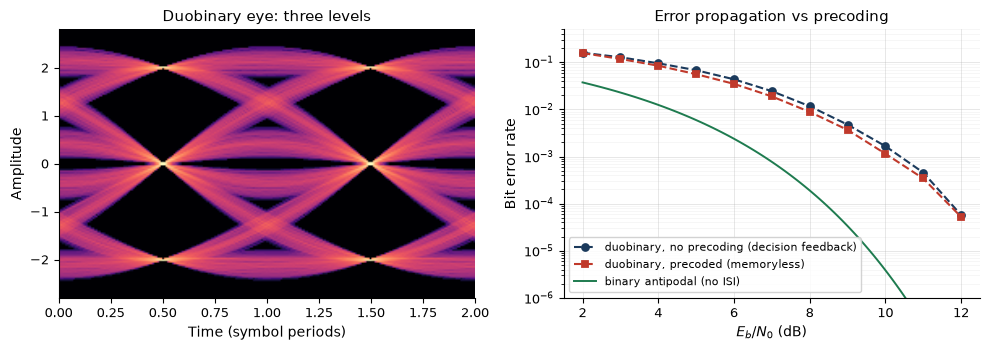

In [25]:
sp = 16
tt = np.arange(-12 * sp, 12 * sp + 1) / sp
p_duo = np.sinc(tt) + np.sinc(tt - 1)
a = 2.0 * cl.random_bits(3000, rng) - 1
up = np.zeros(len(a) * sp); up[::sp] = a
yw = np.convolve(up, p_duo)
f, ax = lk.fig("row2", 1, 2)
d0 = 12 * sp
lk.eye_density(ax[0], yw[d0 - sp // 2 + 50 * sp:-50 * sp], sp, 2, ylim=2.8)
ax[0].set_title("Duobinary eye: three levels")

def duo_ber(ebn0_db, n=400_000):
    b = cl.random_bits(n, rng)
    sigma = np.sqrt(2 / (2 * 10 ** (ebn0_db / 10)))    # Eb = 2 per bit for the ±2-peak duobinary pulse
    # without precoding: a_k = 2 b_k - 1, decide a_k = sign(y_k - a_{k-1}) with feedback
    aa = 2.0 * b - 1
    yy = aa + np.r_[-1.0, aa[:-1]] + sigma * rng.standard_normal(n)
    ah = np.empty(n); prev = -1.0
    for i in range(n):
        ah[i] = 1.0 if yy[i] - prev > 0 else -1.0
        prev = ah[i]
    ber_fb = np.mean((ah > 0) != b)
    # with precoding
    pk = np.cumsum(b) % 2
    ap = 2.0 * pk - 1
    yp = ap + np.r_[-1.0, ap[:-1]] + sigma * rng.standard_normal(n)
    ber_pc = np.mean((np.abs(yp) < 1) != b)
    return ber_fb, ber_pc

eb7 = np.arange(2, 13, 1.0)
r7 = np.array([duo_ber(e) for e in eb7])
ebf = np.linspace(2, 12, 100)
lk.ber_plot(ax[1], eb7, {"duobinary, no precoding (decision feedback)": r7[:, 0],
                         "duobinary, precoded (memoryless)": r7[:, 1]},
            {"binary antipodal (no ISI)": cl.ber_bpsk(ebf)}, x_theory=ebf, ylim=(1e-6, 0.5))
ax[1].set_title("Error propagation vs precoding")
lk.show(f)

**What you should see.** A three-level eye with two openings. Precoded symbol-by-symbol duobinary sits
about 3 dB from binary antipodal signalling at $10^{-4}$ (the eye openings are half the peak-to-peak
swing); an ML sequence detector (Viterbi on the 2-state trellis) recovers most of that. The unprecoded
decision-feedback detector is somewhat worse: each error tends to drag a neighbour with it. At these
error rates the bursts are short, but the precoded receiver has no memory at all, so a burst is
*impossible*, and it is also simpler.

## Key takeaways
* Line codes shape the spectrum: non-zero-mean codes carry spectral lines; Manchester and AMI null DC.
* PRBS and scramblers randomise the line; self-synchronous scramblers multiply errors by the tap count.
* 8b/10b guarantees run length ≤ 5 and bounded DC at 25% overhead; 64b/66b and 128b/130b trade that
  guarantee for 3% and 1.5% overhead.
* Jitter = RJ (Gaussian, unbounded) + DJ (bounded); at $10^{-12}$, TJ = DJ + 14 σ.
* PAM-4 halves the baud rate at a 9.5 dB eye-height cost: it wins when the channel loss slope is steep.
* Duobinary uses controlled ISI to reach the Nyquist bandwidth; precoding removes error propagation.

## Going further (hardware: USRP B200 / GNU Radio)
* The B200 is an RF radio, but its baseband is a serial-link story too: the AD9364 talks to the FPGA
  over LVDS and the FPGA to your PC over USB 3.0, whose physical layer uses 8b/10b at 5 Gb/s.
* Generate PRBS-15 bits in GNU Radio (`GLFSR Source`), send them through `gr02_psk_link.py`, and verify
  the received sequence with a self-synchronising PRBS checker built from Section 3.

## Exercises
1. **(Warm-up)** Derive the PSD of Manchester code from the general formula by treating it as
   polar NRZ with a pulse $p(t) = \mathrm{rect}$ of half width minus its shifted copy.
2. **(Core)** Implement B8ZS (T1) or HDB3 (E1) substitution on top of AMI and show that the maximum run
   of zeros drops to 7 or 3 while the DC null is preserved.
3. **(Core)** Add a decision-feedback equalizer (1–3 taps) after the FFE of Section 6 and measure the
   loss at which PAM-4 stops opening.
4. **(Stretch)** Implement a 2-state Viterbi detector for unprecoded duobinary and show that it closes
   most of the gap to binary antipodal signalling.

In [28]:
lk.summary()

[good] Lab 13 finished in 7.6 s. Self-checks: 0 passed, 0 failed, 4 still to do.